In [18]:
!pip install nd2 cellpose scikit-image

In [62]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import nd2
from cellpose import denoise, models
import subprocess

# Mount AFP network drive
print("Mounting network drive...")
subprocess.run([
    'mount_afp',
    'afp://FletchRAID2._afpovertcp._tcp.local/fletchlab_public',
    '/Volumes/fletchlab_public'
], check=False)

# Set file path
nd2_file_path = "/Volumes/fletchlab_public/Smiti/2026 data/Trogo R01 exploration/2026_1_14-sirpa-tdxcheck/sirpa_spot574.nd2"

# Create output directory for results
output_dir = Path("./segmentation_results")
output_dir.mkdir(exist_ok=True)

print(f"ND2 file: {nd2_file_path}")
print(f"Output directory: {output_dir.absolute()}")

Mounting network drive...
ND2 file: /Volumes/fletchlab_public/Smiti/2026 data/Trogo R01 exploration/2026_1_14-sirpa-tdxcheck/sirpa_spot574.nd2
Output directory: /Users/smiti/Library/Mobile Documents/com~apple~CloudDocs/Github/microscopy_analysis/segmentation_results


mount_afp: the volume is already mounted


In [21]:
# Load ND2 file and extract channels
def load_nd2_channels(file_path):
    """Load nd2 file and extract channels. Channel 1: Orange, Channel 2: Brightfield"""
    nd2_file = nd2.ND2File(file_path)
    image_data = nd2_file.asarray()
    
    # Handle Z-stack: take middle slice
    if len(image_data.shape) == 4:
        image_data = image_data[image_data.shape[0] // 2]
    
    orange_channel = np.array(image_data[0], dtype=np.float32)
    brightfield_channel = np.array(image_data[1], dtype=np.float32)
    
    print(f"Loaded: Orange {orange_channel.shape}, Brightfield {brightfield_channel.shape}")
    return orange_channel, brightfield_channel

orange_channel, brightfield_channel = load_nd2_channels(nd2_file_path)

Loaded: Orange (6221, 6221), Brightfield (6221, 6221)


/var/folders/g0/y4_m300d36s7nrrg4j4vjcj00000gn/T/ipykernel_84524/1770070040.py:17: UserWarning: ND2File file not closed before garbage collection. Please use `with ND2File(...):` context or call `.close()`.
  orange_channel, brightfield_channel = load_nd2_channels(nd2_file_path)


In [22]:
# Check hardware and initialize cellpose model
import time
import platform

print(f"System: {platform.system()} {platform.release()}")
print(f"Processor: {platform.processor()}")

# Check for Apple Silicon
is_apple_silicon = platform.processor() == 'arm64'
print(f"Apple Silicon: {is_apple_silicon}")

print("\nLoading cellpose model...")
start = time.time()
model = models.CellposeModel(model_type='cyto')
elapsed = time.time() - start
print(f"Model loaded in {elapsed:.1f}s")

model_type argument is not used in v4.0.1+. Ignoring this argument...


model_type argument is not used in v4.0.1+. Ignoring this argument...


System: Darwin 24.3.0
Processor: arm
Apple Silicon: False

Loading cellpose model...
Model loaded in 2.4s
Model loaded in 2.4s


In [152]:
# Ring-based segmentation with tophat + local intensity detection
from skimage import filters, feature, morphology, exposure
from scipy import ndimage
import time

def segment_ring_based(image, cache_path=None, min_brightness=None, channel_type='brightfield'):
    """Segment cell bodies using tophat filtering for brightfield, white tophat for orange.

    Args:
        image: Input image array
        cache_path: Path to cache segmentation results
        min_brightness: Minimum brightness threshold (0-1) for filtering dark noise
        channel_type: 'brightfield' or 'orange' - adjusts parameters for each channel
    """
    # Load from cache if available
    if cache_path and Path(cache_path).exists():
        with open(cache_path, 'rb') as f:
            data = pickle.load(f)
        print(f"Loaded cached segmentation")
        return data['masks']

    print(f"Running segmentation on {image.shape} image ({channel_type})...")
    start = time.time()

    # Normalize image
    img_norm = (image - image.min()) / (image.max() - image.min() + 1e-8)

    # Filter out dark noise if min_brightness specified
    if min_brightness is not None:
        dark_mask = img_norm < min_brightness
        img_norm[dark_mask] = 0
        print(f"Filtered out dark pixels below {min_brightness}")

    # Channel-specific segmentation strategy
    if channel_type == 'brightfield':
        # For brightfield: detect dark cell bodies using tophat transform
        img_smooth = filters.gaussian(img_norm, sigma=2.0)

        # Tophat filter - detects dark objects (cell bodies have dark interior)
        footprint = morphology.disk(15)
        tophat = morphology.black_tophat(img_smooth, footprint)

        # Enhance with Gaussian
        tophat_enhanced = filters.gaussian(tophat, sigma=1.5)

        # Threshold - use stricter threshold to avoid noise
        threshold = filters.threshold_otsu(tophat_enhanced) * 1.1
        binary_mask = tophat_enhanced > threshold

        # Label BEFORE dilation/closing to filter size properly
        masks, _ = ndimage.label(binary_mask)
        component_sizes = np.bincount(masks.ravel())
        min_area_bf = 300
        max_area_bf = 5000
        # Remove small noise before morphology
        for label_id in range(1, len(component_sizes)):
            if component_sizes[label_id] < min_area_bf or component_sizes[label_id] > max_area_bf:
                masks[masks == label_id] = 0
        binary_mask = masks > 0

        dilation_radius = 6
        closing_radius = 3

    else:  # orange channel
        # For orange: enhance faint rings then detect with white tophat
        img_smooth = filters.gaussian(img_norm, sigma=0.6)

        # Local contrast enhancement (CLAHE) to boost faint rings
        clahe = exposure.equalize_adapthist(img_smooth, clip_limit=0.01)

        # White tophat - detects bright objects (transfected cell rings)
        footprint = morphology.disk(6)
        tophat = morphology.white_tophat(clahe, footprint)

        # Much higher percentile to reject shot noise - only get strong signals
        threshold = np.percentile(tophat[tophat > 0], 60) if np.any(tophat > 0) else 0
        binary_mask = tophat > threshold

        # Aggressive opening to remove noise artifacts
        binary_mask = morphology.opening(binary_mask, morphology.disk(2))

        dilation_radius = 4
        closing_radius = 4

    # Dilate edges to connect boundaries
    binary_mask = morphology.dilation(binary_mask, morphology.disk(dilation_radius))

    # Close small gaps
    binary_mask = morphology.closing(binary_mask, morphology.disk(closing_radius))

    # Label connected components
    masks, num_features = ndimage.label(binary_mask)

    # Size filtering for orange only (brightfield already filtered above)
    if channel_type == 'orange':
        component_sizes = np.bincount(masks.ravel())
        min_area_orange = 150
        max_area_orange = 1500
        for label_id in range(1, len(component_sizes)):
            size = component_sizes[label_id]
            if size < min_area_orange or size > max_area_orange:
                masks[masks == label_id] = 0

    # Relabel after filtering
    masks, _ = ndimage.label(masks > 0)

    elapsed = time.time() - start
    print(f"Segmentation completed in {elapsed:.1f}s")

    # Save to cache
    if cache_path:
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        with open(cache_path, 'wb') as f:
            pickle.dump({'masks': masks}, f)
        print(f"Cached segmentation")

    return masks

In [153]:
# Clear cache to force fresh segmentation with updated parameters
import shutil
cache_files = [output_dir / "brightfield_masks.pkl", output_dir / "orange_masks.pkl"]
for cache_file in cache_files:
    if cache_file.exists():
        cache_file.unlink()
        print(f"Deleted cache: {cache_file.name}")
print("Cache cleared - next segmentation will run fresh")


Deleted cache: brightfield_masks.pkl
Deleted cache: orange_masks.pkl
Cache cleared - next segmentation will run fresh


In [154]:
# Segment both channels
print("\n=== Segmenting Brightfield Channel ===")
brightfield_masks = segment_ring_based(
    brightfield_channel, 
    cache_path=output_dir / "brightfield_masks.pkl",
    channel_type='brightfield'
)

print("\n=== Segmenting Orange Channel (Ring-based) ===")
# Use very low brightness threshold to capture faint signals
orange_masks = segment_ring_based(
    orange_channel, 
    cache_path=output_dir / "orange_masks.pkl",
    min_brightness=0.05,  # Very low threshold to keep faint transfected cells
    channel_type='orange'
)

print(f"\nBrightfield: {len(np.unique(brightfield_masks)) - 1} cells")
print(f"Orange: {len(np.unique(orange_masks)) - 1} cells")


=== Segmenting Brightfield Channel ===
Running segmentation on (6221, 6221) image (brightfield)...
Segmentation completed in 190.8s
Cached segmentation
Segmentation completed in 190.8s
Cached segmentation

=== Segmenting Orange Channel (Ring-based) ===
Running segmentation on (6221, 6221) image (orange)...

=== Segmenting Orange Channel (Ring-based) ===
Running segmentation on (6221, 6221) image (orange)...
Filtered out dark pixels below 0.05
Filtered out dark pixels below 0.05
Segmentation completed in 36.3s
Cached segmentation
Segmentation completed in 36.3s
Cached segmentation

Brightfield: 1122 cells
Orange: 93 cells

Brightfield: 1122 cells
Orange: 93 cells


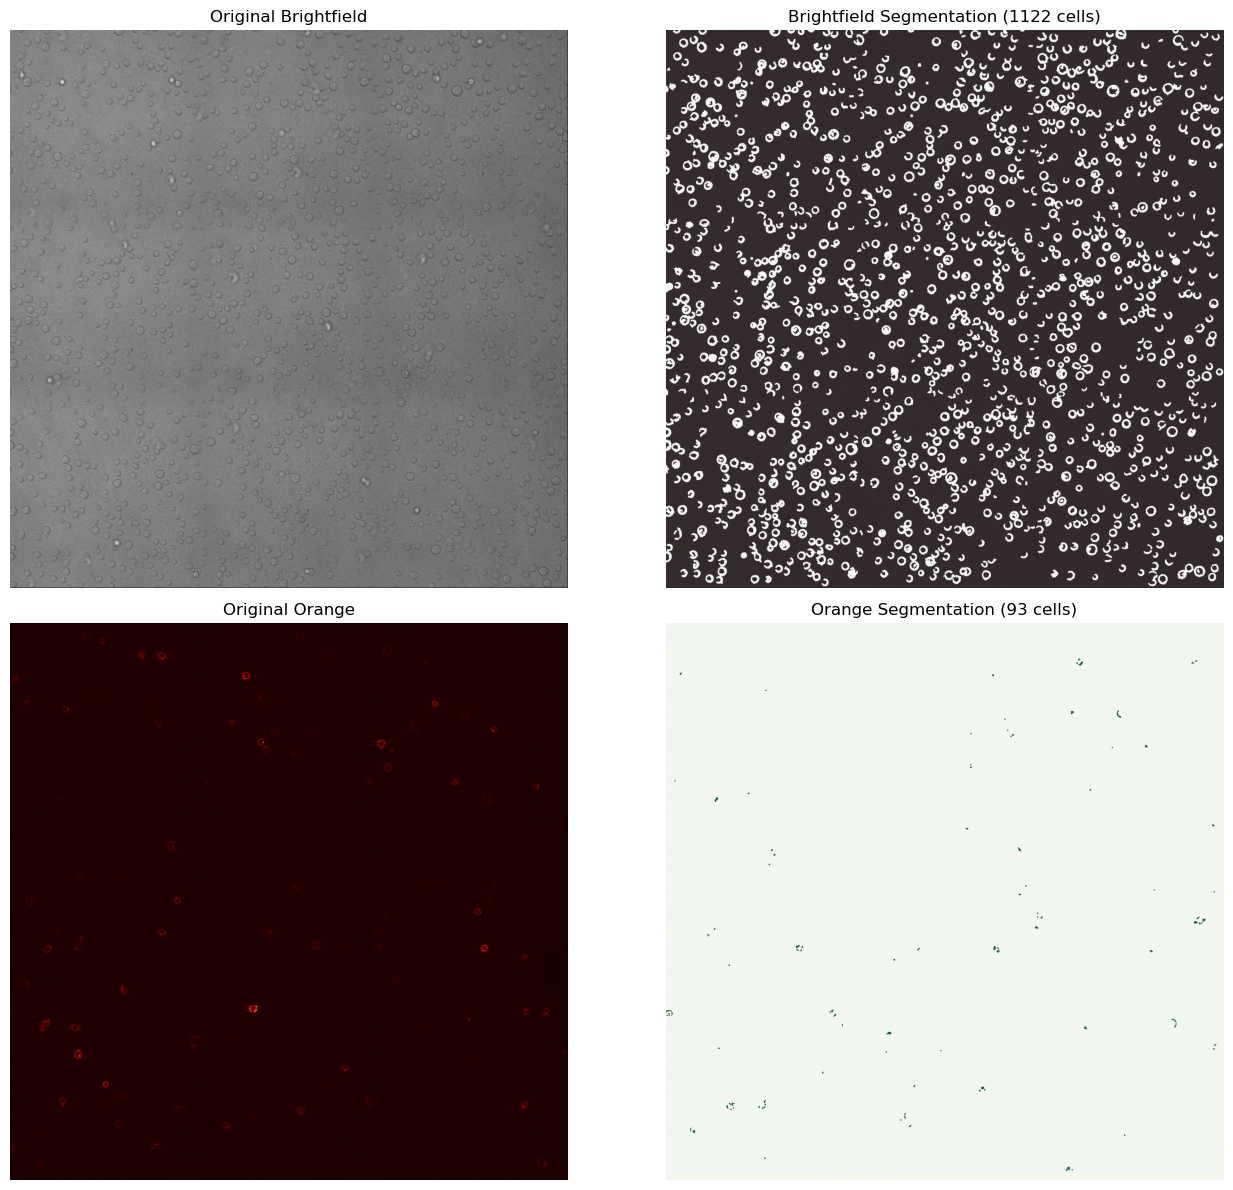

In [155]:
# Visualize segmentations for confirmation
def visualize_segmentations(original_bf, mask_bf, original_orange, mask_orange, output_path=None):
    """Show 2x2 grid of original images and segmentation masks."""
    # Downsample for faster rendering (display only, doesn't affect analysis)
    downsample_factor = 4
    mask_bf_small = mask_bf[::downsample_factor, ::downsample_factor]
    mask_orange_small = mask_orange[::downsample_factor, ::downsample_factor]
    original_bf_small = original_bf[::downsample_factor, ::downsample_factor]
    original_orange_small = original_orange[::downsample_factor, ::downsample_factor]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    axes[0, 0].imshow(original_bf_small, cmap='gray')
    axes[0, 0].set_title('Original Brightfield')
    axes[0, 0].axis('off')
    
    # Show segmentation mask prominently with edges overlay
    bf_edges = mask_bf_small > 0
    axes[0, 1].imshow(original_bf_small, cmap='gray', alpha=0.3)
    axes[0, 1].imshow(bf_edges, cmap='hot', alpha=0.8)
    axes[0, 1].set_title(f'Brightfield Segmentation ({len(np.unique(mask_bf)) - 1} cells)')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(original_orange_small, cmap='hot')
    axes[1, 0].set_title('Original Orange')
    axes[1, 0].axis('off')
    
    # Show orange segmentation with high contrast
    orange_edges = mask_orange_small > 0
    axes[1, 1].imshow(original_orange_small, cmap='gray', alpha=0.2)
    axes[1, 1].imshow(orange_edges, cmap='Greens', alpha=0.9)
    axes[1, 1].set_title(f'Orange Segmentation ({len(np.unique(mask_orange)) - 1} cells)')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    
    if output_path:
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

visualize_segmentations(
    brightfield_channel, brightfield_masks,
    orange_channel, orange_masks,
    output_path=output_dir / "segmentation_visualization.png"
)

In [156]:
# Calculate transfection metrics and save results
def calculate_transfection_metrics(brightfield_masks, orange_masks, output_dir=None):
    """Calculate and save transfection efficiency metrics."""
    total_cells = len(np.unique(brightfield_masks)) - 1
    transfected_cells = len(np.unique(orange_masks)) - 1
    efficiency = (transfected_cells / total_cells * 100) if total_cells > 0 else 0
    
    print(f"\nTotal cells: {total_cells}")
    print(f"Transfected cells: {transfected_cells}")
    print(f"Efficiency: {efficiency:.2f}%\n")
    
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Save results text
        with open(output_dir / "transfection_results.txt", 'w') as f:
            f.write(f"Total cells: {total_cells}\n")
            f.write(f"Transfected cells: {transfected_cells}\n")
            f.write(f"Efficiency: {efficiency:.2f}%\n")
        
        # Save masks comparison
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        axes[0].imshow(brightfield_masks, cmap='nipy_spectral')
        axes[0].set_title(f'Brightfield ({total_cells} cells)')
        axes[0].axis('off')
        axes[1].imshow(orange_masks, cmap='nipy_spectral')
        axes[1].set_title(f'Orange ({transfected_cells} cells)')
        axes[1].axis('off')
        plt.tight_layout()
        plt.savefig(output_dir / "segmentation_masks_comparison.png", dpi=150, bbox_inches='tight')
        plt.close()
    
    return {'total': total_cells, 'transfected': transfected_cells, 'efficiency': efficiency}

metrics = calculate_transfection_metrics(brightfield_masks, orange_masks, output_dir=output_dir)


Total cells: 1122
Transfected cells: 93
Efficiency: 8.29%

